## FABlib API References Examples

- [fablib.show_config](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.show_config)
- [fablib.list_sites](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.list_sites)
- [fablib.list_hosts](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.list_hosts)
- [fablib.new_slice](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.new_slice)
- [slice.add_node](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.add_node)
- [slice.submit](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.submit)
- [slice.get_nodes](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.get_nodes)
- [slice.list_nodes](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.list_nodesß)
- [slice.show](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.show)
- [node.execute](https://fabric-fablib.readthedocs.io/en/latest/node.html#fabrictestbed_extensions.fablib.node.Node.execute)
- [slice.delete](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.delete) 

This file serves to run an automated script that executes the experiments. 

In [1]:
import datetime
import json
import asyncio
from configuration import SLICE_NAME
from utils import upload_and_execute_file, override_configuration_files, upload_file, execute_file
import pandas as pd

from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager

fablib = fablib_manager()

fablib.show_config();

Orchestrator,orchestrator.fabric-testbed.net
Credential Manager,cm.fabric-testbed.net
Core API,uis.fabric-testbed.net
Artifact Manager,artifacts.fabric-testbed.net
Token File,/home/fabric/.tokens.json
Project ID,49f65ad7-d8a2-4ab9-8ca0-ba777a2e0ea2
Bastion Host,bastion.fabric-testbed.net
Bastion Username,apipilikas_0000444352
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub
Slice Private Key File,/home/fabric/work/fabric_config/slice_key


In [2]:
%%time
image = "default_ubuntu_24"

# Please adhere to the following regex for naming: /[a-z][a-z0-9]+/
# note: see above, renamed the agent names to only have hyphens, not underscores 

node_configurations = [
    {
        "type": "control",
        "cores": 2,
        "ram": 8,
        "disk": 100,
        "site": "AMST",
        "host": "amst-w3.fabric-testbed.net",
    },
    {
        "type": "dynamos",
        "cores": 4,
        "ram": 16,
        "disk": 100,
        "site": "AMST",
        "host": "amst-w3.fabric-testbed.net",
    },
    {
        "type": "agent",
        "name": "server",
        "cores": 4,
        "ram": 16,
        "disk": 100,
        "site": "AMST",
        "host": "amst-w3.fabric-testbed.net",
    },
    {
        "type": "agent",
        "name": "clientone",
        "cores": 4,
        "ram": 16,
        "disk": 100,
        "site": "LOSA",
        "host": "losa-w3.fabric-testbed.net",
    },
    {
        "type": "agent",
        "name": "clienttwo",
        "cores": 8,
        "ram": 16,
        "disk": 100,
        "site": "TOKY",
        "host": "toky-w3.fabric-testbed.net",
    },
    {
        "type": "agent",
        "name": "clientthree",
        "cores": 8,
        "ram": 16,
        "disk": 100,
        "site": "AMST",
        "host": "amst-w3.fabric-testbed.net",
    },
    {
        "type": "thirdparty",
        "name": "surf",
        "cores": 8,
        "ram": 16,
        "disk": 100,
        "site": "TOKY",
        "host": "toky-w3.fabric-testbed.net",
    }
]

sites = list(set([configuration["site"] for configuration in node_configurations]))
agents = [configuration["name"] for configuration in node_configurations if configuration["type"] == "agent"]
thirdparties = [configuration["name"] for configuration in node_configurations if configuration["type"] == "thirdparty"]

def create_node(slice, configuration):
    if (configuration["type"] == "control"): 
        configuration["name"] = "control"

    if (configuration["type"] == "dynamos"): 
        configuration["name"] = "dynamos"
    
    return slice.add_node(name=configuration["name"], 
                          site=configuration["site"], 
                          host=configuration["host"], 
                          cores=configuration["cores"], 
                          ram=configuration["ram"], 
                          disk=configuration["disk"], 
                          validate=True, 
                          raise_exception=True, 
                          image=image)
    

CPU times: user 16 μs, sys: 0 ns, total: 16 μs
Wall time: 20 μs


In [3]:
%%time
slice = fablib.get_slice(name=SLICE_NAME);
nodes = slice.get_nodes();

User: apipilikas@gmail.com bastion key is valid!
Configuration is valid
CPU times: user 359 ms, sys: 18 ms, total: 377 ms
Wall time: 4.4 s


In [4]:
%%time
slice = fablib.get_slice(name=SLICE_NAME);
nodes = slice.get_nodes();

for node in nodes:
    print(node.get_name())
    ssh_command = node.get_ssh_command().replace(
        "-i /home/fabric/work/fabric_config/slice_key", "-i ~/.ssh/keys/FABRIC-slice_key"
    ).replace(
        "-F /home/fabric/work/fabric_config/ssh_config ", ""
    )
    
    print(ssh_command);

control
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe67:fd10
dynamos
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe98:1cce
server
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe50:837d
aggregator
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fef7:ced3
authority
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe4a:4d9a
clientone
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe54:989
clienttwo
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe7c:4f5a
clientthree
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe1c:e52c
surf
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:610:2d0:fabc:f816:3eff:fe9e:98e1
CPU times: user 191 ms, sys: 2.14 ms, total: 193 ms
Wall time: 449 ms


In [5]:
%%time
def get_ip(node):
    interface = node.get_interface(network_name=f"Network-{node.get_site()}")
    return interface.get_ip_addr()

nodes_dict= dict()

for node in nodes[:]:
    ip = get_ip(node)
    name = node.get_name()
    nodes_dict[name] = {"ip": ip, "node": node}
    print(f"{name}: {ip}")

print(nodes_dict)


control: 10.145.1.2
dynamos: 10.145.1.3
server: 10.145.1.4
aggregator: 10.145.1.5
authority: 10.145.1.6
clientone: 10.145.1.7
clienttwo: 10.145.1.8
clientthree: 10.145.1.9
surf: 10.145.1.10
{'control': {'ip': '10.145.1.2', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3d7b5bcd70>}, 'dynamos': {'ip': '10.145.1.3', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3d7b5a6490>}, 'server': {'ip': '10.145.1.4', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3d7b5a60d0>}, 'aggregator': {'ip': '10.145.1.5', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3d7b5a6210>}, 'authority': {'ip': '10.145.1.6', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3d7b5a6350>}, 'clientone': {'ip': '10.145.1.7', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3d7b5a5f90>}, 'clienttwo': {'ip': '10.145.1.8', 'node': <fabrictestbed_extensions.fablib.node.Node object at 0x7d3d7b5a65d0>}, 'clientthree': {'ip': '1

In [6]:
main_node=nodes_dict['control']['node']
print(f"The main node for now on is [{main_node.get_name()}]")

The main node for now on is [control]


## Sidecar RCA experiment

In [6]:
runs_no = 10

In [44]:
# Baseline experiment for sidecar
main_node.execute(f"""
cd scattered-directive-energy-monitoring 
cd energy-monitoring-pipeline 
$HOME/miniconda/envs/py-venv/bin/python -u execute_experiment.py -b -s -i {runs_no}"""
                 )

============= Execute experiment (baseline) (sidecar) =============

> Starting new experiment run [1/10]

> Idle period
Waiting for idle period ...
Executing [query_range] query [sum(increase(kepler_container_joules_total{container_name="sidecar"}[2m])) by (pod_name)].

> Active period
Executing [query_range] query [sum(increase(kepler_container_joules_total{container_name="sidecar"}[2m])) by (pod_name)].

> Summary
Experiment elapsed time: 360.20932936668396 s (0:06:00.209329)
Active period elapsed time: 240.09944081306458 s (0:04:00.099441)
Executing [query_range] query [sum(increase(kepler_container_joules_total{container_name="sidecar"}[2m])) by (pod_name)] from [1779210408.7759345] to [1779210768.9852638]
Saved file to [output/experiment_0_metrics.csv]!

> Starting new experiment run [2/10]

> Idle period
Waiting for idle period ...
Executing [query_range] query [sum(increase(kepler_container_joules_total{container_name="sidecar"}[2m])) by (pod_name)].

> Active period
Executing 

('============= Execute experiment (baseline) (sidecar) =============\n\n> Starting new experiment run [1/10]\n\n> Idle period\nWaiting for idle period ...\nExecuting [query_range] query [sum(increase(kepler_container_joules_total{container_name="sidecar"}[2m])) by (pod_name)].\n\n> Active period\nExecuting [query_range] query [sum(increase(kepler_container_joules_total{container_name="sidecar"}[2m])) by (pod_name)].\n\n> Summary\nExperiment elapsed time: 360.20932936668396 s (0:06:00.209329)\nActive period elapsed time: 240.09944081306458 s (0:04:00.099441)\nExecuting [query_range] query [sum(increase(kepler_container_joules_total{container_name="sidecar"}[2m])) by (pod_name)] from [1779210408.7759345] to [1779210768.9852638]\nSaved file to [output/experiment_0_metrics.csv]!\n\n> Starting new experiment run [2/10]\n\n> Idle period\nWaiting for idle period ...\nExecuting [query_range] query [sum(increase(kepler_container_joules_total{container_name="sidecar"}[2m])) by (pod_name)].\n\n>

In [7]:
# Experiment for sidecar
main_node.execute(f"""
cd scattered-directive-energy-monitoring 
cd energy-monitoring-pipeline 
$HOME/miniconda/envs/py-venv/bin/python -u calculate_average.py"""
                 )

============= Average experiments =============
Saved metrics means file to [output/average_metrics_mean.csv]!
Saved metrics std file to [output/average_metrics_mean.csv]!
Saved final average experiments file to [output/average_experiments.json]!


('============= Average experiments =============\nSaved metrics means file to [output/average_metrics_mean.csv]!\nSaved metrics std file to [output/average_metrics_mean.csv]!\nSaved final average experiments file to [output/average_experiments.json]!\n',
 '')

In [8]:
# Baseline metrics (back-up and renaming)
main_node.download_file("output/baseline_data_metrics.csv", "scattered-directive-energy-monitoring/energy-monitoring-pipeline/output/average_metrics_mean.csv")
upload_file(main_node, "output/baseline_data_metrics.csv", "scattered-directive-energy-monitoring/energy-monitoring-pipeline/output/baseline_data_metrics.csv")


Uploading file from local path [output/baseline_data_metrics.csv] to remote path [scattered-directive-energy-monitoring/energy-monitoring-pipeline/output/baseline_data_metrics.csv] ...


## Install requirements

In [23]:
main_node.execute("""
cd ~/scattered-directive-energy-monitoring/energy-monitoring-pipeline
sudo apt update && sudo apt install -y python3-pip
python3 -m pip install --no-cache-dir -r requirements.txt --break-system-packages
""")



Hit:1 http://nova.clouds.archive.ubuntu.com/ubuntu noble InRelease
Hit:2 http://nova.clouds.archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:3 http://nova.clouds.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:4 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:5 https://prod-cdn.packages.k8s.io/repositories/isv:/kubernetes:/core:/stable:/v1.30/deb  InRelease
Hit:6 https://packages.buildkite.com/helm-linux/helm-debian/any any InRelease
Reading package lists...
Building dependency tree...
Reading state information...
6 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists...


Building dependency tree...
Reading state information...
python3-pip is already the newest version (24.0+dfsg-1ubuntu1.3).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 623.0 kB/s eta 0:00:00
     ━━━━

("Hit:1 http://nova.clouds.archive.ubuntu.com/ubuntu noble InRelease\nHit:2 http://nova.clouds.archive.ubuntu.com/ubuntu noble-updates InRelease\nHit:3 http://nova.clouds.archive.ubuntu.com/ubuntu noble-backports InRelease\nHit:4 http://security.ubuntu.com/ubuntu noble-security InRelease\nHit:5 https://prod-cdn.packages.k8s.io/repositories/isv:/kubernetes:/core:/stable:/v1.30/deb  InRelease\nHit:6 https://packages.buildkite.com/helm-linux/helm-debian/any any InRelease\nReading package lists...\nBuilding dependency tree...\nReading state information...\n6 packages can be upgraded. Run 'apt list --upgradable' to see them.\nReading package lists...\nBuilding dependency tree...\nReading state information...\npython3-pip is already the newest version (24.0+dfsg-1ubuntu1.3).\n0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.\nDefaulting to user installation because normal site-packages is not writeable\nCollecting pandas (from -r requirements.txt (line 1))\n  Downloading pandas-

## Automated experiments

In [7]:
# Override the experiment configuration
upload_file(main_node, "overriden_files/experiments_configuration.json", "/home/ubuntu/scattered-directive-energy-monitoring/scripts/experiments_configuration.json")

Uploading file from local path [overriden_files/experiments_configuration.json] to remote path [/home/ubuntu/scattered-directive-energy-monitoring/scripts/experiments_configuration.json] ...


In [11]:
# Experiment
# main_node.execute("sudo apt update && sudo apt install -y python-is-python3")
main_node.execute("""
cd ~/scattered-directive-energy-monitoring
./scripts/execute_experiments.sh fabric
                 """)

=============== Started experiments execution ===============


=============== Starting experiment ===============
 Name: pa_baseline_event_driven | Repetitions: 3
 Iterations: 10 | Policy-aware: true

-i 10 -op pa_baseline_event_driven -f -pa
=============== Started experiment execution [ 1 / 3 ] ===============
[Step 1/5] Running Dynamos Configuration...

[Step 1/5] Running DYNAMOS Configuration (Attempt 1 of 3)...

=============== Started setting up DYNAMOS (fabric) ===============

Setting up paths...

Agents discovered: server,clientone,clienttwo,clientthree

Generating agents and third parties charts...

Adding agents...
- agent 'server'
- agent 'clientone'
- agent 'clienttwo'
- agent 'clientthree'

Adding third parties...
definitions_example.json copied over definitions.json to ensure a clean file
Generating RabbitMQ password...

Replacing tokens...

Installing namespaces...

Release "namespaces" does not exist. Installing it now.
NAME: namespaces
LAST DEPLOYED: Wed Jul  8 09:5

KeyboardInterrupt: 

## Downloading the whole directory

In [21]:
main_node.download_directory("output/experiments", "/home/ubuntu/scattered-directive-energy-monitoring/energy-monitoring-pipeline/experiments/fabric")

/opt/conda/lib/python3.13/site-packages/fabrictestbed_extensions/fablib/node.py:2414: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_file.extractall(local_directory_path)


'success'

## Executing individual experiment run

In [ ]:
main_node.execute("""
cd ~/scattered-directive-energy-monitoring
./scripts/run_experiment.sh fabric 1 -i 10 -op baseline_event_driven -f
                 """)

## Collecting pod metrics

In [9]:
# Experiment
# main_node.execute("sudo apt update && sudo apt install -y python-is-python3")
main_node.execute("""
cd scattered-directive-energy-monitoring
cd energy-monitoring-pipeline 
$HOME/miniconda/envs/py-venv/bin/python collect_pod_metrics.py
                 """)


> Searching namespace 'aggregator' for pods starting with 'evangelos-pipilikas'...

>  Pod name: evangelos-pipilikas-60bd5a8daggregator1-w22p8
    - Ready:  0.067 minutes (4.000s)
    - ContainersReady:  0.067 minutes (4.000s)
    - PodScheduled:  0.000 minutes (0.000s)
    - PodReadyToStartContainers:  0.067 minutes (4.000s)
    - Initialized:  0.000 minutes (0.000s)
    - Total:  0.524 minutes (31.466s)

> Searching namespace 'authority' for pods starting with 'evangelos-pipilikas'...

>  Pod name: evangelos-pipilikas-60bd5a8dauthority1-72dsc
    - Ready:  0.067 minutes (4.000s)
    - ContainersReady:  0.067 minutes (4.000s)
    - PodScheduled:  0.000 minutes (0.000s)
    - PodReadyToStartContainers:  0.067 minutes (4.000s)
    - Initialized:  0.000 minutes (0.000s)
    - Total:  0.527 minutes (31.614s)

> Searching namespace 'server' for pods starting with 'evangelos-pipilikas'...

>  Pod name: evangelos-pipilikas-60bd5a8dserver1-8xdgq
    - Ready:  0.067 minutes (4.000s)
    - Con

("\n> Searching namespace 'aggregator' for pods starting with 'evangelos-pipilikas'...\n\n>  Pod name: evangelos-pipilikas-60bd5a8daggregator1-w22p8\n    - Ready:  0.067 minutes (4.000s)\n    - ContainersReady:  0.067 minutes (4.000s)\n    - PodScheduled:  0.000 minutes (0.000s)\n    - PodReadyToStartContainers:  0.067 minutes (4.000s)\n    - Initialized:  0.000 minutes (0.000s)\n    - Total:  0.524 minutes (31.466s)\n\n> Searching namespace 'authority' for pods starting with 'evangelos-pipilikas'...\n\n>  Pod name: evangelos-pipilikas-60bd5a8dauthority1-72dsc\n    - Ready:  0.067 minutes (4.000s)\n    - ContainersReady:  0.067 minutes (4.000s)\n    - PodScheduled:  0.000 minutes (0.000s)\n    - PodReadyToStartContainers:  0.067 minutes (4.000s)\n    - Initialized:  0.000 minutes (0.000s)\n    - Total:  0.527 minutes (31.614s)\n\n> Searching namespace 'server' for pods starting with 'evangelos-pipilikas'...\n\n>  Pod name: evangelos-pipilikas-60bd5a8dserver1-8xdgq\n    - Ready:  0.067 

## Resolving bug with these packages

In [35]:
main_node.execute("""
rm -rf /home/ubuntu/.local/lib/python3.12/site-packages/pandas*
rm -rf /home/ubuntu/.local/lib/python3.12/site-packages/numpy*
python3 -m pip install --no-cache-dir --force-reinstall pandas numpy requests --break-system-packages
""")

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 621.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 273.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.3/133.3 kB 327.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 304.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 303.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 293.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 323.9 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  C

('Defaulting to user installation because normal site-packages is not writeable\nCollecting pandas\n  Downloading pandas-3.0.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)\n     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 621.8 kB/s eta 0:00:00\nCollecting numpy\n  Downloading numpy-2.5.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)\nCollecting requests\n  Downloading requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)\nCollecting python-dateutil>=2.8.2 (from pandas)\n  Downloading python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)\nCollecting charset_normalizer<4,>=2 (from requests)\n  Downloading charset_normalizer-3.4.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)\n     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.1 MB/s eta 0:00:00\nCollecting idna<4,>=2.5 (from requests)\n  Downloading idna-3.18-py3-none-any.whl.metadata (6.1 kB)\

## Plots

In [ ]:
import matplotlib.pyplot as plt
import time

# Visualization of the results
data = pd.read_csv("output/da_data_metrics.csv", index_col="timestamp", parse_dates=True)

plt.figure(figsize=(15, 8))

for column_name in data.columns:
    if column_name.endswith("_anomaly") and "_cpu_usage_" in column_name:
        anomaly_score_column = f"{column_name}_score"
        
        # Plot normal instances
        normal = data[data[column_name] == 1]
        plt.scatter(normal.index, normal[anomaly_score_column], s=10)
        
        # Plot anomalies
        anomalies = data[data[column_name] == -1]
        plt.scatter(anomalies.index, anomalies[anomaly_score_column], marker='x', label=column_name)

plt.xlabel("Timestamp")
plt.ylabel("Anomaly Score")

# Place legend outside the plot to save space
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2, fontsize='small')
plt.tight_layout()

plt.show()

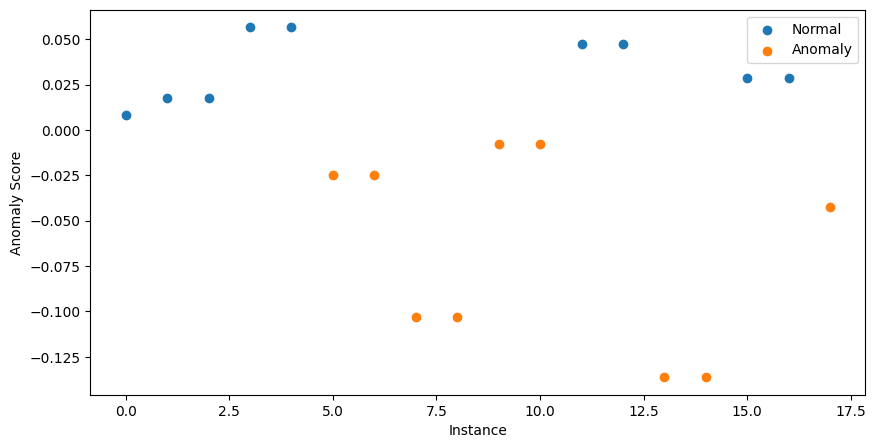

In [17]:
# Visualization of the results

data = pd.read_csv("output/da_data_metrics.csv")

time_seconds = data.index * 15

plt.figure(figsize=(10, 5))

column_name = "clientone_sidecar_energy_anomaly"
anomaly_score_column = f"{column_name}_score"

# Plot normal instances

normal = data[data[column_name] == 1]

plt.scatter(normal.index, normal[anomaly_score_column], label='Normal')



# Plot anomalies (The lower, the more abnormal.)

anomalies = data[data[column_name] == -1]

plt.scatter(anomalies.index, anomalies[anomaly_score_column], label='Anomaly')

plt.xlabel("Instance")

plt.ylabel("Anomaly Score")

plt.legend()

plt.show()

In [59]:
# main_node.execute('$HOME/miniconda/envs/py-venv/bin/pip install "numpy<2.0.0"')

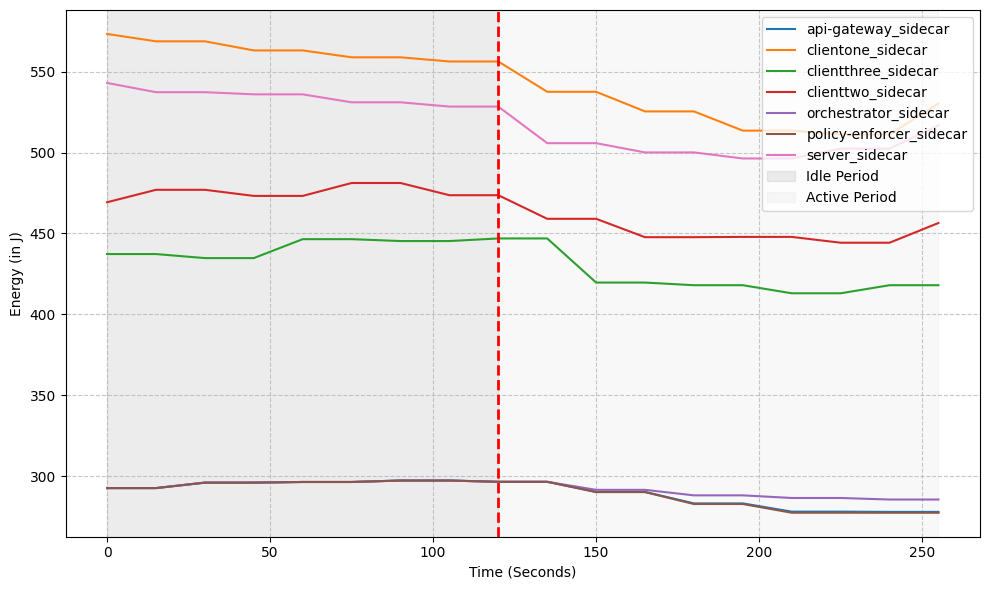

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("output/data_metrics.csv")

time_seconds = data.index * 15  

# Initialize the plot
plt.figure(figsize=(10, 6))

min_time = time_seconds.min()  # This will be 0
max_time = time_seconds.max()
cutoff_time = 120  # The 120-second mark

for column_name in data.columns:
    if column_name.endswith("_energy"):        
        energy_data = data[column_name]
        container_name = column_name.replace("_energy", "")
        
        plt.plot(time_seconds, energy_data, linestyle='-', label=container_name)


plt.axvline(x=cutoff_time, color='red', linestyle='--', linewidth=2)
plt.axvspan(min_time, cutoff_time, color='gray', alpha=0.15, label='Idle Period')
plt.axvspan(cutoff_time, max_time, color='lightgray', alpha=0.15, label='Active Period')

plt.xlabel('Time (Seconds)') 
plt.ylabel('Energy (in J)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

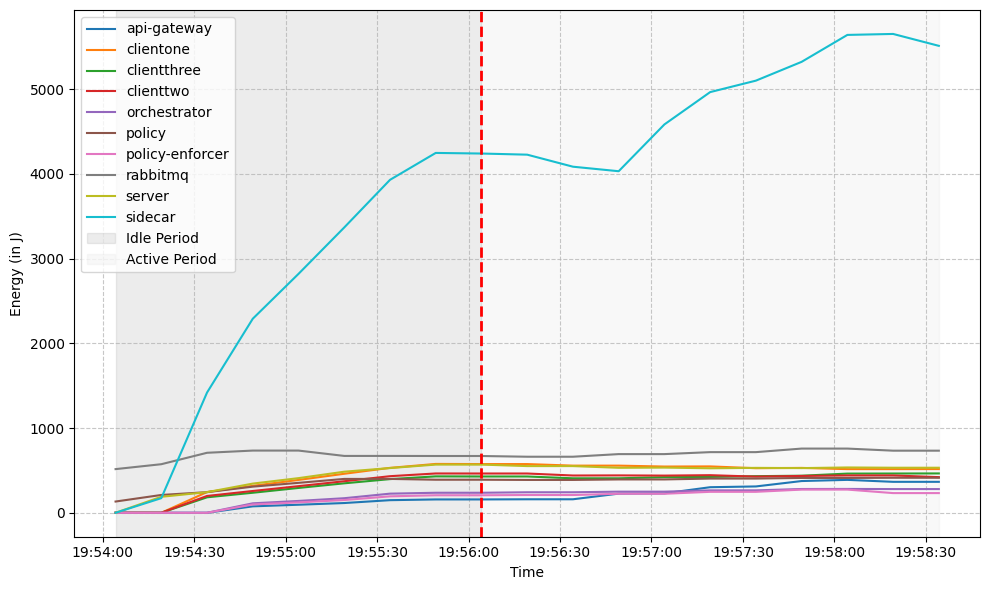

In [24]:
import matplotlib.pyplot as plt
import time

# Visualization of the results
data = pd.read_csv("output/experiment_metrics.csv", index_col="timestamp", parse_dates=True)

# Initialize the plot
plt.figure(figsize=(10, 6))

min_time = data.index.min()
max_time = data.index.max()
cutoff_time = min_time + pd.Timedelta(seconds=120)

for column_name in data.columns:
    if column_name.endswith("_energy"):        
        energy_data = data[column_name]
        container_name = column_name.replace("_energy", "")
        plt.plot(energy_data.index, energy_data, linestyle='-', label=container_name)

# Plot the _energy column. 
# If you have a time column (e.g., 'timestamp'), replace client_one_data.index with client_one_data['timestamp']
# plt.plot(client_one_data.index, client_one_data, 
#          marker='o', linestyle='-', color='#1f77b4', label='Client 1 Energy')

# Add formatting and labels
# plt.title('Energy Consumption: Client 1')


# 3. Add a subtle background shade for the 120s Idle Period 
# (This sits behind the lines and doesn't change their colors)
plt.axvline(x=cutoff_time, color='red', linestyle='--', linewidth=2)
plt.axvspan(min_time, cutoff_time, color='gray', alpha=0.15, label='Idle Period')
plt.axvspan(cutoff_time, max_time, color='lightgray', alpha=0.15, label='Active Period')

plt.xlabel('Time')
plt.ylabel('Energy (in J)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()